## Etapa 4: Extração de features

In [2]:
import os, cv2, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern

base_path = r"E:\VISÃO COMPUTACIONAL\Projeto Final\DATASET\normal"
prep_base = r"E:\VISÃO COMPUTACIONAL\Projeto Final\DATASET\preprocessed\normal"
mask_base = r"E:\VISÃO COMPUTACIONAL\Projeto Final\DATASET\masks"
output_dir = r"E:\VISÃO COMPUTACIONAL\Projeto Final\OUTPUTS"
os.makedirs(output_dir, exist_ok=True)

def carregar_imagem_bgr(caminho):
    with open(caminho, 'rb') as f:
        dados = np.frombuffer(f.read(), np.uint8)
    img = cv2.imdecode(dados, cv2.IMREAD_COLOR)
    return img

def carregar_par(caminho_img, caminho_mask):
    img = carregar_imagem_bgr(caminho_img)
    if img is None:
        return None, None
    mascara = carregar_mascara(caminho_mask)
    return img, mascara

def carregar_mascara(caminho):
    with open(caminho, 'rb') as f:
        dados = np.frombuffer(f.read(), np.uint8)
    mascara = cv2.imdecode(dados, cv2.IMREAD_GRAYSCALE)
    return mascara

caminho_mask_teste = r"E:\VISÃO COMPUTACIONAL\Projeto Final\DATASET\masks\fresh\freshapples\imagem1.png"
caminho_img_teste = caminho_mask_teste.replace('masks', 'preprocessed\\normal')

img_bgr, mascara = carregar_par(caminho_img_teste, caminho_mask_teste)

mascara_bin = (mascara > 0).astype(np.uint8)
labeled = label(mascara_bin)
props = regionprops(labeled)

if props:
    maior = max(props, key=lambda r: r.area)
    area = maior.area
    perimetro = maior.perimeter
    excentricidade = maior.eccentricity
    solidez = maior.solidity
    extensao = maior.extent
    diam_eq = maior.equivalent_diameter_area
    circularidade = 4 * np.pi * area / (perimetro ** 2) if perimetro > 0 else 0
    print(area, perimetro, excentricidade, solidez, extensao, diam_eq, circularidade)

contornos, _ = cv2.findContours(mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
if contornos:
    maior_contorno = max(contornos, key=cv2.contourArea)
    momentos = cv2.moments(maior_contorno)
    hu = cv2.HuMoments(momentos)
    hu_log = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)
    hu_lista = hu_log.flatten().tolist()

mean, stddev = cv2.meanStdDev(img_bgr, mask=mascara)
medias = mean.flatten()   # [B, G, R]
desvios = stddev.flatten()

gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
gray_masked = cv2.bitwise_and(gray, gray, mask=mascara)
x, y, w, h = cv2.boundingRect(maior_contorno)
roi_gray = gray[y:y+h, x:x+w]
glcm = graycomatrix(roi_gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
contraste = graycoprops(glcm, 'contrast')[0,0]
homogeneidade = graycoprops(glcm, 'homogeneity')[0,0]
energia = graycoprops(glcm, 'energy')[0,0]
correlacao = graycoprops(glcm, 'correlation')[0,0]

img_bgr, mascara = carregar_par(caminho_img_teste, caminho_mask_teste)
print("Imagem carregada:", img_bgr is not None)
print("Máscara carregada:", mascara is not None)


84549.0 1355.3494218736669 0.312269911016429 0.9784404943757812 0.7838045795865394 328.10231676690927 0.5783833597063365
Imagem carregada: True
Máscara carregada: True


In [3]:
def extrair_features(img_bgr, mascara):
    feats = {}
 
    mascara_bin = (mascara > 0).astype(np.uint8)
    labeled = label(mascara_bin)
    props = regionprops(labeled)
    if props:
        maior = max(props, key=lambda r: r.area)
        feats['area'] = maior.area
        feats['perimetro'] = maior.perimeter
        feats['excentricidade'] = maior.eccentricity
        feats['solidez'] = maior.solidity
        feats['extensao'] = maior.extent
        feats['diam_eq'] = maior.equivalent_diameter_area
        feats['circularidade'] = 4 * np.pi * maior.area / (maior.perimeter ** 2) if maior.perimeter > 0 else 0
    else:
        for key in ['area', 'perimetro', 'excentricidade', 'solidez', 'extensao', 'diam_eq', 'circularidade']:
            feats[key] = 0.0
    
    contornos, _ = cv2.findContours(mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contornos:
        maior_contorno = max(contornos, key=cv2.contourArea)
        momentos = cv2.moments(maior_contorno)
        hu = cv2.HuMoments(momentos)
        hu_log = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)
        for i, val in enumerate(hu_log.flatten(), 1):
            feats[f'hu{i}'] = val
    else:
        for i in range(1, 8):
            feats[f'hu{i}'] = 0.0
    
    mean, stddev = cv2.meanStdDev(img_bgr, mask=mascara)
    medias = mean.flatten()
    desvios = stddev.flatten()
    for canal, nome in enumerate(['B', 'G', 'R']):
        feats[f'media_{nome}'] = medias[canal]
        feats[f'std_{nome}'] = desvios[canal]

    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    if contornos:
        x, y, w, h = cv2.boundingRect(maior_contorno)
        roi_gray = gray[y:y+h, x:x+w]
        if roi_gray.size > 0:
            glcm = graycomatrix(roi_gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
            feats['contraste'] = graycoprops(glcm, 'contrast')[0,0]
            feats['homogeneidade'] = graycoprops(glcm, 'homogeneity')[0,0]
            feats['energia'] = graycoprops(glcm, 'energy')[0,0]
            feats['correlacao'] = graycoprops(glcm, 'correlation')[0,0]
        else:
            for key in ['contraste','homogeneidade','energia','correlacao']:
                feats[key] = 0.0
    else:
        for key in ['contraste','homogeneidade','energia','correlacao']:
            feats[key] = 0.0
    
    return feats

feats_teste = extrair_features(img_bgr, mascara)
print(feats_teste)

{'area': np.float64(84549.0), 'perimetro': np.float64(1355.3494218736669), 'excentricidade': 0.312269911016429, 'solidez': np.float64(0.9784404943757812), 'extensao': np.float64(0.7838045795865394), 'diam_eq': np.float64(328.10231676690927), 'circularidade': np.float64(0.5783833597063365), 'hu1': np.float64(0.792320838670641), 'hu2': np.float64(4.158525896881078), 'hu3': np.float64(4.457582325333913), 'hu4': np.float64(6.365426087414258), 'hu5': np.float64(-9.992916295957317), 'hu6': np.float64(-8.61665173065729), 'hu7': np.float64(9.998719088458026), 'media_B': np.float64(70.35090803960209), 'std_B': np.float64(35.76116482201942), 'media_G': np.float64(164.8253543065504), 'std_G': np.float64(33.02878186113068), 'media_R': np.float64(146.9237341137321), 'std_R': np.float64(36.42027299358282), 'contraste': np.float64(11.919961319596833), 'homogeneidade': np.float64(0.5463489378356983), 'energia': np.float64(0.12173004879531804), 'correlacao': np.float64(0.9977407081612583)}


## Vetor X (por item)

In [6]:
import os

classes = ["fresh", "rotten"]
imagens_por_classe = {}

for classe in classes:
    pasta_classe = os.path.join(base_path, classe)
    imagens = []
    for raiz, subpastas, arquivos in os.walk(pasta_classe):
        for arquivo in arquivos:
            if arquivo.lower().endswith(('.png', '.jpg', '.jpeg')):
                imagens.append(os.path.join(raiz, arquivo))
    imagens.sort()
    imagens_por_classe[classe] = imagens
    print(f"Classe '{classe}': {len(imagens)} imagens encontradas.")

Classe 'fresh': 1143 imagens encontradas.
Classe 'rotten': 1143 imagens encontradas.


In [7]:
import time

registros = []
total_imagens = sum(len(v) for v in imagens_por_classe.values())
processadas = 0

print(f"Iniciando extração de features para {total_imagens} imagens...\n")

for classe in classes:
    print(f"Processando classe: {classe}")
    imagens_classe = imagens_por_classe[classe]
    for i, caminho_original in enumerate(imagens_classe, start=1):
        rel_path = os.path.relpath(caminho_original, base_path)
        caminho_img = os.path.join(prep_base, rel_path)
        caminho_mask = os.path.join(mask_base, rel_path).replace('.jpg', '.png')
        
        img, mascara = carregar_par(caminho_img, caminho_mask)
        if img is None or mascara is None:
            print(f"  ⚠️  Falha ao carregar: {rel_path}")
            continue
        
        feats = extrair_features(img, mascara)
        feats['classe'] = classe
        feats['arquivo'] = rel_path
        registros.append(feats)
        
        if i % 100 == 0:
            processadas_ate_aqui = len(registros)
            print(f"  ... {i}/{len(imagens_classe)} imagens de '{classe}' processadas ({processadas_ate_aqui} features extraídas até agora)")
    
    print(f"  ✅ Classe '{classe}' concluída. Total extraído da classe: {len([r for r in registros if r['classe'] == classe])}\n")

processadas = len(registros)
print(f"Extração finalizada! {processadas} features extraídas de {total_imagens} imagens.")

# Salva os CSVs
df = pd.DataFrame(registros)
X = df.drop(columns=['classe', 'arquivo'])
y = df['classe']

X.to_csv(os.path.join(output_dir, 'X.csv'), index=False)
y.to_csv(os.path.join(output_dir, 'y.csv'), index=False)

print(f"X.csv e y.csv salvos em: {output_dir}")
print(f"Dimensões: X={X.shape}, y={y.shape}")

Iniciando extração de features para 2286 imagens...

Processando classe: fresh
  ... 100/1143 imagens de 'fresh' processadas (100 features extraídas até agora)
  ... 200/1143 imagens de 'fresh' processadas (200 features extraídas até agora)
  ... 300/1143 imagens de 'fresh' processadas (300 features extraídas até agora)
  ... 400/1143 imagens de 'fresh' processadas (400 features extraídas até agora)
  ... 500/1143 imagens de 'fresh' processadas (500 features extraídas até agora)
  ... 600/1143 imagens de 'fresh' processadas (600 features extraídas até agora)
  ... 700/1143 imagens de 'fresh' processadas (700 features extraídas até agora)
  ... 800/1143 imagens de 'fresh' processadas (800 features extraídas até agora)
  ... 900/1143 imagens de 'fresh' processadas (900 features extraídas até agora)
  ... 1000/1143 imagens de 'fresh' processadas (1000 features extraídas até agora)
  ... 1100/1143 imagens de 'fresh' processadas (1100 features extraídas até agora)
  ✅ Classe 'fresh' concluí

DIMENSÕES
X: (2286, 24)  |  y: (2286,)

Colunas de X:
['area', 'perimetro', 'excentricidade', 'solidez', 'extensao', 'diam_eq', 'circularidade', 'hu1', 'hu2', 'hu3', 'hu4', 'hu5', 'hu6', 'hu7', 'media_B', 'std_B', 'media_G', 'std_G', 'media_R', 'std_R', 'contraste', 'homogeneidade', 'energia', 'correlacao']

PRIMEIRAS 5 LINHAS DE X


,area,perimetro,excentricidade,solidez,extensao,diam_eq,circularidade,hu1,hu2,hu3,...,media_B,std_B,media_G,std_G,media_R,std_R,contraste,homogeneidade,energia,correlacao
0,84549.0,1355.349422,0.312270,0.978440,0.783805,328.102317,0.578383,0.792321,4.158526,4.457582,...,70.350908,35.761165,164.825354,33.028782,146.923734,36.420273,11.919961,0.546349,0.121730,0.997741
1,114198.0,3762.708078,0.706993,0.786683,0.607462,381.315368,0.101360,0.705013,2.360993,2.839668,...,58.591632,37.330519,62.753276,46.688881,127.039717,39.136385,39.890201,0.490013,0.188740,0.997074
2,26069.0,712.340187,0.287155,0.972978,0.783182,182.186942,0.645594,0.797442,4.327023,6.150439,...,89.875830,23.450519,186.658944,26.464534,167.660516,24.100764,51.032871,0.447071,0.058932,0.988647
3,22669.0,876.849855,0.348290,0.934727,0.757527,169.891340,0.370503,0.794559,3.868517,4.377566,...,70.604658,35.790052,64.941903,34.687421,162.901981,35.151347,49.033345,0.327078,0.099332,0.994436
4,94662.0,1548.361615,0.159051,0.973138,0.766246,347.170566,0.496182,0.797509,5.071800,5.019494,...,69.282530,35.825515,70.209992,36.183420,175.156254,30.222365,40.650310,0.416458,0.090924,0.994932



INFO E NULOS
<class 'pandas.DataFrame'>
RangeIndex: 2286 entries, 0 to 2285
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   area            2286 non-null   float64
 1   perimetro       2286 non-null   float64
 2   excentricidade  2286 non-null   float64
 3   solidez         2286 non-null   float64
 4   extensao        2286 non-null   float64
 5   diam_eq         2286 non-null   float64
 6   circularidade   2286 non-null   float64
 7   hu1             2286 non-null   float64
 8   hu2             2286 non-null   float64
 9   hu3             2286 non-null   float64
 10  hu4             2286 non-null   float64
 11  hu5             2286 non-null   float64
 12  hu6             2286 non-null   float64
 13  hu7             2286 non-null   float64
 14  media_B         2286 non-null   float64
 15  std_B           2286 non-null   float64
 16  media_G         2286 non-null   float64
 17  std_G           2286 non-null 

,area,perimetro,excentricidade,solidez,extensao,diam_eq,circularidade,hu1,hu2,hu3,...,media_B,std_B,media_G,std_G,media_R,std_R,contraste,homogeneidade,energia,correlacao
count,2286.000000,2286.000000,2286.000000,2286.000000,2286.000000,2286.000000,2286.000000,2286.000000,2286.000000,2286.000000,...,2286.000000,2286.000000,2286.000000,2286.000000,2286.000000,2286.000000,2286.000000,2286.000000,2286.000000,2286.000000
mean,55295.037183,1594.042719,0.610222,0.819040,0.606560,249.899872,0.368032,0.667204,2.752767,3.618680,...,74.740758,28.224735,133.947282,34.046064,189.361853,31.760285,41.880365,0.439688,0.132666,0.993272
std,35206.608454,957.189771,0.251421,0.156527,0.162785,89.204052,0.233125,0.167565,1.287895,1.338280,...,18.420351,8.076381,38.900881,10.048848,33.126451,10.694649,29.829225,0.149371,0.120649,0.004771
min,821.000000,121.982756,0.017635,0.298433,0.152535,32.331558,0.018737,-0.061440,-0.054986,0.000000,...,23.199203,8.279395,29.732510,5.897457,54.552047,4.582859,2.221394,0.106591,0.011501,0.958617
25%,26222.000000,960.996302,0.391019,0.702198,0.478993,182.720789,0.168456,0.587243,1.689072,2.554838,...,61.190566,22.365070,107.115859,26.593217,164.840139,23.832667,23.389857,0.337001,0.054786,0.991920
50%,52284.000000,1388.809794,0.583583,0.866152,0.653996,258.011735,0.335754,0.757370,2.888618,3.718277,...,72.629271,27.328580,133.737572,33.720427,190.759864,33.245128,35.333649,0.421857,0.098495,0.994456
75%,78155.000000,1915.689826,0.854587,0.956686,0.746029,315.452115,0.522585,0.792502,3.746303,4.603564,...,87.406513,33.469432,163.834298,40.196675,219.367945,39.808743,50.611663,0.511017,0.145400,0.996213
max,256360.000000,8014.193898,0.991596,0.994559,0.915002,571.321004,0.905633,0.798095,6.855251,8.751426,...,166.005714,70.036753,226.703320,82.827243,246.451130,69.392899,280.420422,0.873771,0.630016,0.999258


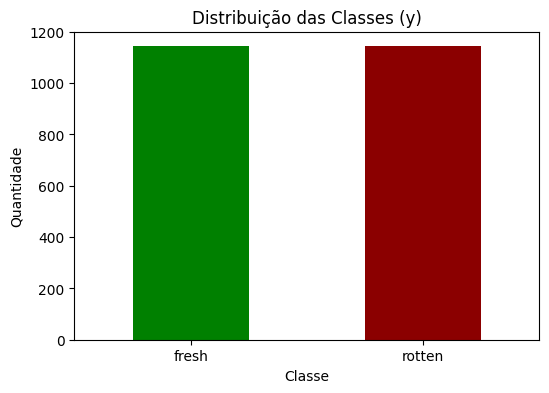

In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt

output_dir = r"E:\VISÃO COMPUTACIONAL\Projeto Final\OUTPUTS"

X = pd.read_csv(os.path.join(output_dir, 'X.csv'))
y = pd.read_csv(os.path.join(output_dir, 'y.csv')).squeeze()

print("=" * 50)
print("DIMENSÕES")
print(f"X: {X.shape}  |  y: {y.shape}")
print("\nColunas de X:")
print(X.columns.tolist())

print("\n" + "=" * 50)
print("PRIMEIRAS 5 LINHAS DE X")
display(X.head())

print("\n" + "=" * 50)
print("INFO E NULOS")
print(X.info())
print("\nValores nulos por coluna:")
print(X.isnull().sum())

print("\n" + "=" * 50)
print("DISTRIBUIÇÃO DAS CLASSES")
print(y.value_counts())
print(f"\nBalanceamento: {y.value_counts(normalize=True).round(2)}")

print("\n" + "=" * 50)
print("ESTATÍSTICAS DAS FEATURES")
display(X.describe())

plt.figure(figsize=(6, 4))
y.value_counts().plot(kind='bar', color=['green', 'darkred'])
plt.title('Distribuição das Classes (y)')
plt.xlabel('Classe')
plt.ylabel('Quantidade')
plt.xticks(rotation=0)
plt.show()